# SPACESHIP TITANIC 🚀 - EDA + ML approaches
**ML COMPETITION**

*author*: **Giacomo Cavalca** - PhD student in Data science

*mail*: gcavalcaphd@gmail.com

<img src= "https://img.freepik.com/premium-photo/spaceship-grunge-interior-with-view-planet-earth_117023-176.jpg?w=2000" alt ="Titanic" style='width: 75%; margin-left: 12.5%
'>

<div style="color:white;
           display:fill;
           background-color:#b0c4de;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px;
           display:flex;
           flex-direction: row;">

<h1 style="padding: 2rem;
          color:white;
          text-align:center;
          margin:0 auto;
          font-size:3rem;">
   TABLE OF CONTENTS:
</h1>
 
</div>
<div style="
           display:fill;
           background-color:#b0c4de;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px;
           display:flex;
           flex-direction: row;
           justify-content: center"
     >
<ul style="
           background-color:#b0c4de;
           margin-left: 2rem;
               ">

<li style="color: white;
           font-size:1.75rem;">
<text >
 SETTINGS AND DATA LOADING
</text>
</li>
<li style="color: white;
           font-size:1.75rem;">

<text >
 EXPLORATORY DATA ANALYSIS
</text>
</li>

    
<li style="color: white;
           font-size:1.75rem;">
<text >
  DATA PREPROCESSING
</text>
</li>

 <li style="color: white;
           font-size:1.75rem;">
<text >
  MODEL SELECTION AND ML 
</text>
</li> 
    
</ul>
</div>

<div id = 3 style="color:white;    
           display:fill;
           border-radius:5px;
           background-color:#b0c4de;
           font-size:100%;
           font-family:Verdana;
           letter-spacing:0.5px;
           display:flex;
            justify-content:center;">

<h2 style="padding: 2rem;
              color:white;
          text-align:center;
          margin:0 auto;
          ">
    SETTINGS AND DATA LOADING
</h2>
</div>

# IMPORT LIBRARIES

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from termcolor import colored

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors  import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier

In [2]:
root_dir = '/kaggle/input/spaceship-titanic'
files = os.path.join(root_dir)
filenames = os.listdir(files)
print(filenames)

['sample_submission.csv', 'train.csv', 'test.csv']


In [3]:
#TRAIN DATA
train_data = pd.read_csv(os.path.join(root_dir,'train.csv'))
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
#TEST DATA
test_data = pd.read_csv(os.path.join(root_dir,'test.csv'))
test_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [5]:
print(colored(f"Training data","blue"),"-> ROWS:",train_data.shape[0],"COLUMNS:",train_data.shape[1])
print(colored(f"Test data","red"),"-> ROWS:",test_data.shape[0],"COLUMNS:",test_data.shape[1])

Training data -> ROWS: 8693 COLUMNS: 14
Test data -> ROWS: 4277 COLUMNS: 13


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
train_data.describe(include='all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8492,8476,8494,8511,8514.000000,8490,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8493,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Gollux Reedall,True
freq,1,4602,5439,8,5915,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.489021,NaN,666.717663,1611.489240,604.696458,1136.705535,1145.717189,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,47.000000,76.000000,27.000000,59.000000,46.000000,NaN,NaN


<div id = 3 style="color:white;    
           display:fill;
           border-radius:5px;
           background-color:#b0c4de;
           font-size:100%;
           font-family:Verdana;
           letter-spacing:0.5px;
           display:flex;
            justify-content:center;">

<h2 style="padding: 2rem;
              color:white;
          text-align:center;
          margin:0 auto;
          ">
    EXPLORATORY DATA ANALYSIS
</h2>
</div>

# **MISSING VALUES VISUALIZATION**

In [8]:
train_data.isna().any()

PassengerId     False
HomePlanet       True
CryoSleep        True
Cabin            True
Destination      True
Age              True
VIP              True
RoomService      True
FoodCourt        True
ShoppingMall     True
Spa              True
VRDeck           True
Name             True
Transported     False
dtype: bool

In [9]:
def percentageOfnull(df):
    percentage = ((df.isna().sum()/df.isna().count())*100).sort_values(ascending=False)
    count = df.isna().sum().sort_values(ascending=False)
    diff = pd.concat([count,percentage],axis=1,keys=['Null Count','Null Percentage'])
    return diff

TRAINING SET
Missing values:
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64


<AxesSubplot:title={'center':'TRAINING SET - missing values'}>

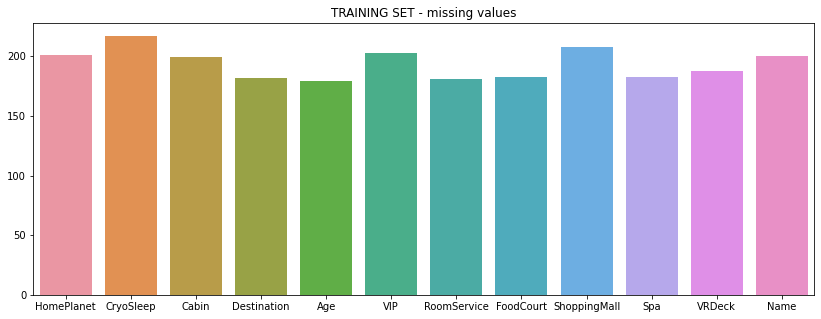

In [10]:
nan_feats_tr = train_data.columns[train_data.isna().any()].tolist()
n_nans_tr = train_data[nan_feats_tr].isna().sum()
print(f"TRAINING SET\nMissing values:\n{n_nans_tr}")
plt.figure(figsize=(14,5))
plt.title("TRAINING SET - missing values")
sns.barplot(y=n_nans_tr,x=nan_feats_tr)

Text(0.5, 1.0, 'TRAINING SET - missing values distribution')

<Figure size 1008x360 with 0 Axes>

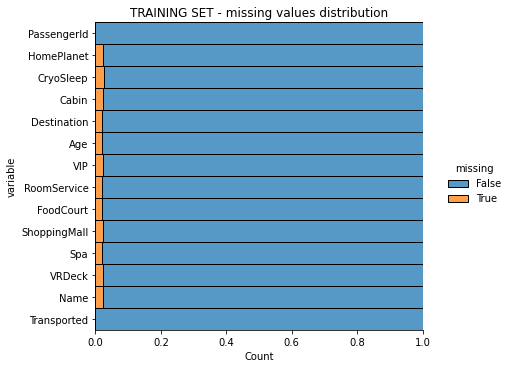

In [11]:
plt.figure(figsize=(14,5))
sns.displot(
    data=train_data.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)
plt.title("TRAINING SET - missing values distribution")

In [12]:
percentageOfnull(train_data)

,Null Count,Null Percentage
CryoSleep,217,2.496261
ShoppingMall,208,2.392730
VIP,203,2.335212
HomePlanet,201,2.312205
Name,200,2.300702
Cabin,199,2.289198
VRDeck,188,2.162660
FoodCourt,183,2.105142
Spa,183,2.105142
Destination,182,2.093639


TESTING SET
Missing values:
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


<AxesSubplot:title={'center':'TESTING SET - missing values'}>

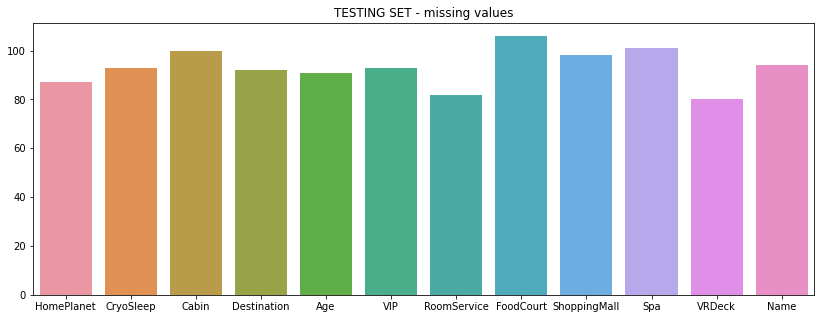

In [13]:
nan_feats_te = test_data.columns[test_data.isna().any()].tolist()
n_nans_te = test_data[nan_feats_te].isna().sum()
print(f"TESTING SET\nMissing values:\n{n_nans_te}")
plt.figure(figsize=(14,5))
plt.title("TESTING SET - missing values")
sns.barplot(y=n_nans_te,x=nan_feats_te)

Text(0.5, 1.0, 'TESTING SET - missing values distribution')

<Figure size 1008x360 with 0 Axes>

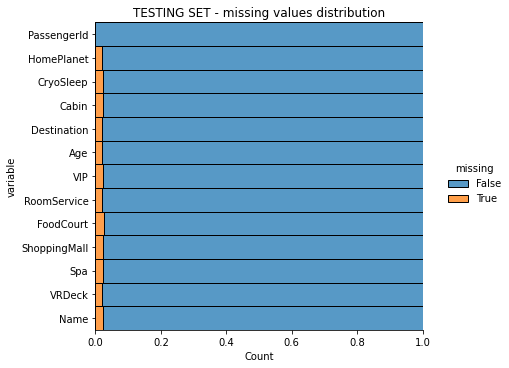

In [14]:
plt.figure(figsize=(14,5))
sns.displot(
    data=test_data.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)
plt.title("TESTING SET - missing values distribution")

In [15]:
percentageOfnull(test_data)

,Null Count,Null Percentage
FoodCourt,106,2.478373
Spa,101,2.361468
Cabin,100,2.338087
ShoppingMall,98,2.291326
Name,94,2.197802
CryoSleep,93,2.174421
VIP,93,2.174421
Destination,92,2.151040
Age,91,2.127660
HomePlanet,87,2.034136


***PASSENGER ID***

PassengerId is a unique Id for each passenger so in general it could be discarded, but in this case it contains two subfeatures:
- gggg which indicates a group a passenger is travelling with
- pp which is the number of the passenger within the group

**TRAINING SET**

In [16]:
#Create 2 new features: gggg and pp
gggg_pp = train_data['PassengerId'].apply(lambda x: x.split('_')).values
gggg = list(map(lambda x: x[0], gggg_pp))
pp = list(map(lambda x: x[1], gggg_pp))
train_data['gggg'] = gggg
train_data['pp'] = pp
train_data['pp'] = train_data['pp'].astype('int64')

In [17]:
mode = train_data["gggg"].mode()[0]
maxP_inGroup = len(train_data[train_data["gggg"] == mode])
print("The maximum number of passengers in a single group is",maxP_inGroup)

The maximum number of passengers in a single group is 8


In [18]:
train_data[train_data["gggg"] == mode] #proof

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,gggg,pp
910,0984_01,Earth,False,G/150/S,TRAPPIST-1e,45.0,False,0.0,1.0,13.0,0.0,873.0,Wen Woodwin,False,0984,1
911,0984_02,Earth,False,F/182/S,TRAPPIST-1e,24.0,False,0.0,0.0,718.0,0.0,0.0,NaN,False,0984,2
912,0984_03,Earth,False,G/150/S,TRAPPIST-1e,23.0,False,0.0,0.0,490.0,0.0,319.0,Morrie Sweekstarks,False,0984,3
913,0984_04,Earth,True,G/150/S,TRAPPIST-1e,30.0,False,0.0,0.0,0.0,0.0,0.0,Lyde Sweekstarks,True,0984,4
914,0984_05,Earth,False,F/182/S,55 Cancri e,20.0,False,0.0,11.0,0.0,136.0,1088.0,Greggy Sweekstarks,False,0984,5
915,0984_06,Earth,True,G/150/S,TRAPPIST-1e,22.0,False,0.0,0.0,0.0,0.0,0.0,Walley Sweekstarks,True,0984,6
916,0984_07,Earth,True,G/150/S,PSO J318.5-22,NaN,False,0.0,0.0,0.0,0.0,0.0,Shery Flemaney,False,0984,7
917,0984_08,Earth,True,G/150/S,TRAPPIST-1e,71.0,False,0.0,0.0,0.0,0.0,0.0,Alancy Flemaney,True,0984,8


Value Counts based on the group size:

Gr. size, Count
1    4805
2    1682
3    1020
4     412
5     265
7     231
6     174
8     104
Name: group_size, dtype: int64


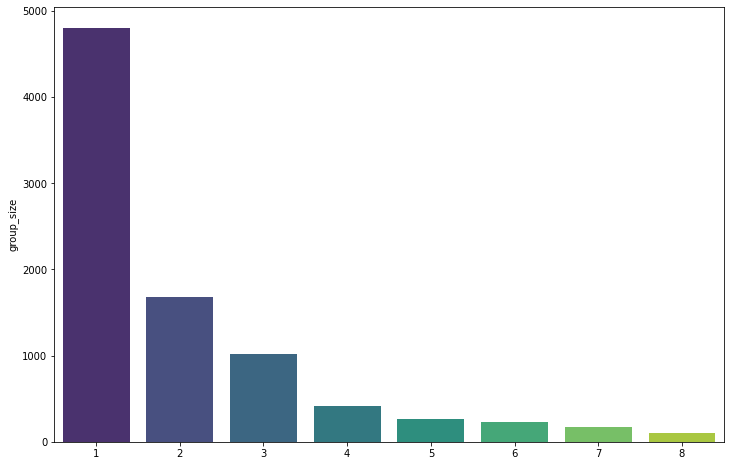

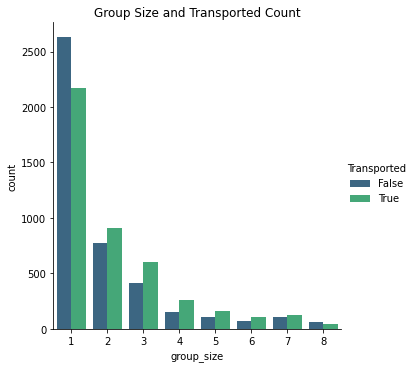

In [19]:
train_data['group_size'] = 0
for i in range(maxP_inGroup):
    curr_gggg = train_data[train_data['pp'] == i + 1]['gggg'].to_numpy()
    train_data.loc[train_data['gggg'].isin(curr_gggg), ['group_size']] = i + 1

plt.figure(figsize=(12,8))
print(colored("Value Counts based on the group size:\n", 'cyan', attrs=['underline', 'bold']))
print(colored("Gr. size, Count", 'blue', attrs=['bold']))
print(train_data['group_size'].value_counts())
sns.barplot(y=train_data['group_size'].value_counts(), x=np.unique(train_data['pp']), palette='viridis')
plt.show()
sns.catplot(x="group_size",  kind="count", hue='Transported', data=train_data, palette='viridis').set(title='Group Size and Transported Count')
plt.show()

**TESTING SET**

In [20]:
gggg_pp = test_data['PassengerId'].apply(lambda x: x.split('_')).values
gggg = list(map(lambda x: x[0], gggg_pp))
pp = list(map(lambda x: x[1], gggg_pp))
test_data['gggg'] = gggg
test_data['pp'] = pp
test_data['pp'] = test_data['pp'].astype('int64')

In [21]:
mode = test_data["gggg"].mode()[0]
maxP_inGroup = len(test_data[test_data["gggg"] == mode])
print("The maximum number of passengers in the same group is",maxP_inGroup)

The maximum number of passengers in the same group is 8


Value Counts based on the group size:

Gr. size, Count
1    2340
2     908
3     486
4     204
5     115
7      98
6      78
8      48
Name: group_size, dtype: int64


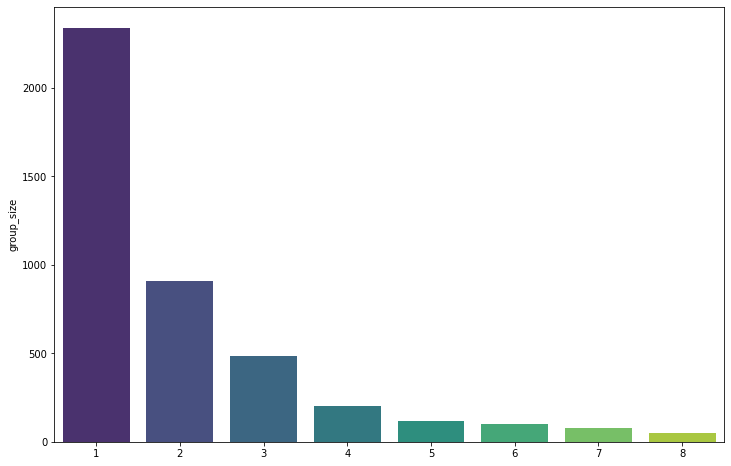

In [22]:
test_data['group_size'] = 0
for i in range(maxP_inGroup):
    curr_gggg = test_data[test_data['pp'] == i + 1]['gggg'].to_numpy()
    test_data.loc[test_data['gggg'].isin(curr_gggg), ['group_size']] = i + 1

plt.figure(figsize=(12,8))
print(colored("Value Counts based on the group size:\n", 'cyan', attrs=['underline', 'bold']))
print(colored("Gr. size, Count", 'blue', attrs=['bold']))
print(test_data['group_size'].value_counts())
sns.barplot(y=test_data['group_size'].value_counts(), x=np.unique(test_data['pp']), palette='viridis')
plt.show()

In [23]:
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,gggg,pp,group_size
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,1,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,1,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,1,2
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,2,2
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,1,1


In [24]:
print(len(train_data[train_data["group_size"] == 1]))
print(len(train_data[train_data["group_size"] != 1]))

4805
3888


In [25]:
#Create a new feature InGroup to indicate if a passenger is alone or in group
train_data["InGroup"] = train_data["group_size"]==1
test_data["InGroup"] = test_data["group_size"]==1

In [26]:
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,gggg,pp,group_size,InGroup
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,1,1,True
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,1,1,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,1,2,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,2,2,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,1,1,True


In [27]:
test_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,gggg,pp,group_size,InGroup
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning,0013,1,1,True
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers,0018,1,1,True
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus,0019,1,1,True
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter,0021,1,1,True
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez,0023,1,1,True


**CABIN**

In [28]:
train_data["Deck"] = train_data["Cabin"].apply(lambda x: str(x).split("/")[0] if(np.all(pd.notnull(x))) else x)
test_data["Deck"] = test_data["Cabin"].apply(lambda x: str(x).split("/")[0] if(np.all(pd.notnull(x))) else x)
train_data["Num"] = train_data["Cabin"].apply(lambda x: int(str(x).split("/")[1]) if(np.all(pd.notnull(x))) else x)
test_data["Num"] = test_data["Cabin"].apply(lambda x: int(str(x).split("/")[1]) if(np.all(pd.notnull(x))) else x)
train_data["Side"] = train_data["Cabin"].apply(lambda x: str(x).split("/")[2] if(np.all(pd.notnull(x))) else x)
test_data["Side"] = test_data["Cabin"].apply(lambda x: str(x).split("/")[2] if(np.all(pd.notnull(x))) else x)

In [29]:
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Transported,gggg,pp,group_size,InGroup,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,Maham Ofracculy,False,0001,1,1,True,B,0.0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,44.0,Juanna Vines,True,0002,1,1,True,F,0.0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,49.0,Altark Susent,False,0003,1,2,False,A,0.0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,193.0,Solam Susent,False,0003,2,2,False,A,0.0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,2.0,Willy Santantines,True,0004,1,1,True,F,1.0,S


In [30]:
#Save PassengerId for the submission
Id_test_list = test_data["PassengerId"].tolist()

train_data.drop("PassengerId",axis=1,inplace=True)
test_data.drop("PassengerId",axis=1,inplace=True)
train_data.drop("Cabin",axis=1,inplace=True)
test_data.drop("Cabin",axis=1,inplace=True)
train_data.drop("Name",axis=1,inplace=True)
test_data.drop("Name",axis=1,inplace=True)
train_data.drop("gggg",axis=1,inplace=True)
test_data.drop("gggg",axis=1,inplace=True)
train_data.drop("pp",axis=1,inplace=True)
test_data.drop("pp",axis=1,inplace=True)
train_data.drop("group_size",axis=1,inplace=True)
test_data.drop("group_size",axis=1,inplace=True)

In [31]:
train_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,InGroup,Deck,Num,Side
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,True,B,0.0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,True,F,0.0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,False,A,0.0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,False,A,0.0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,True,F,1.0,S


In [32]:
test_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,InGroup,Deck,Num,Side
0,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,True,G,3.0,S
1,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,True,F,4.0,S
2,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,True,C,0.0,S
3,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,True,C,1.0,S
4,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,True,F,5.0,S


In [33]:
train_data.dtypes

HomePlanet       object
CryoSleep        object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported        bool
InGroup            bool
Deck             object
Num             float64
Side             object
dtype: object

# FILLING NAN VALUES

In [34]:
num_feats = list(train_data.select_dtypes(include='number'))
categ_feats = list(train_data.select_dtypes(exclude='number'))
test_categ_feats = list(test_data.select_dtypes(exclude='number'))
print(num_feats)
print(categ_feats)
print(test_categ_feats)

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Num']
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported', 'InGroup', 'Deck', 'Side']
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'InGroup', 'Deck', 'Side']


In [35]:
#replace missing values in each numerical feature with the median
for feat in num_feats:
    train_data[feat].fillna(train_data[feat].median(), inplace=True)
    test_data[feat].fillna(test_data[feat].median(), inplace=True)

#replace missing values in each categorical feature with the most frequent value
for feat in categ_feats:
    train_data[feat].fillna(train_data[feat].value_counts().index[0],inplace=True)
    
for feat in test_categ_feats:
    test_data[feat].fillna(test_data[feat].value_counts().index[0],inplace=True)

In [36]:
#proof
print(colored("TRAINING SET\n",attrs=['bold']),percentageOfnull(train_data),end="\n\n")
print(colored("TESTING SET\n",attrs=['bold']),percentageOfnull(test_data),end="\n\n")

TRAINING SET
               Null Count  Null Percentage
HomePlanet             0              0.0
CryoSleep              0              0.0
Destination            0              0.0
Age                    0              0.0
VIP                    0              0.0
RoomService            0              0.0
FoodCourt              0              0.0
ShoppingMall           0              0.0
Spa                    0              0.0
VRDeck                 0              0.0
Transported            0              0.0
InGroup                0              0.0
Deck                   0              0.0
Num                    0              0.0
Side                   0              0.0

TESTING SET
               Null Count  Null Percentage
HomePlanet             0              0.0
CryoSleep              0              0.0
Destination            0              0.0
Age                    0              0.0
VIP                    0              0.0
RoomService            0              0.0
FoodCo

In [37]:
#print categories of each categorical column after removing unnecessary columns
for col in train_data.select_dtypes(exclude=['number']):
  print(f'{col:-<30},{train_data[col].unique()}')

HomePlanet--------------------,['Europa' 'Earth' 'Mars']
CryoSleep---------------------,[False  True]
Destination-------------------,['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e']
VIP---------------------------,[False  True]
Transported-------------------,[False  True]
InGroup-----------------------,[ True False]
Deck--------------------------,['B' 'F' 'A' 'G' 'E' 'D' 'C' 'T']
Side--------------------------,['P' 'S']


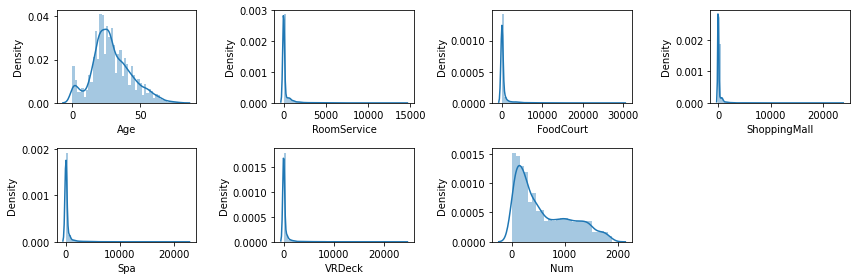

In [38]:
#Plot distribution of numerical columns
import warnings

warnings.filterwarnings('ignore')

fig = plt.figure(figsize=(12,4))
for i,col in enumerate(num_feats):
    ax = fig.add_subplot(2,4,i+1)
    sns.distplot(train_data[col])
    
fig.tight_layout()
plt.show()

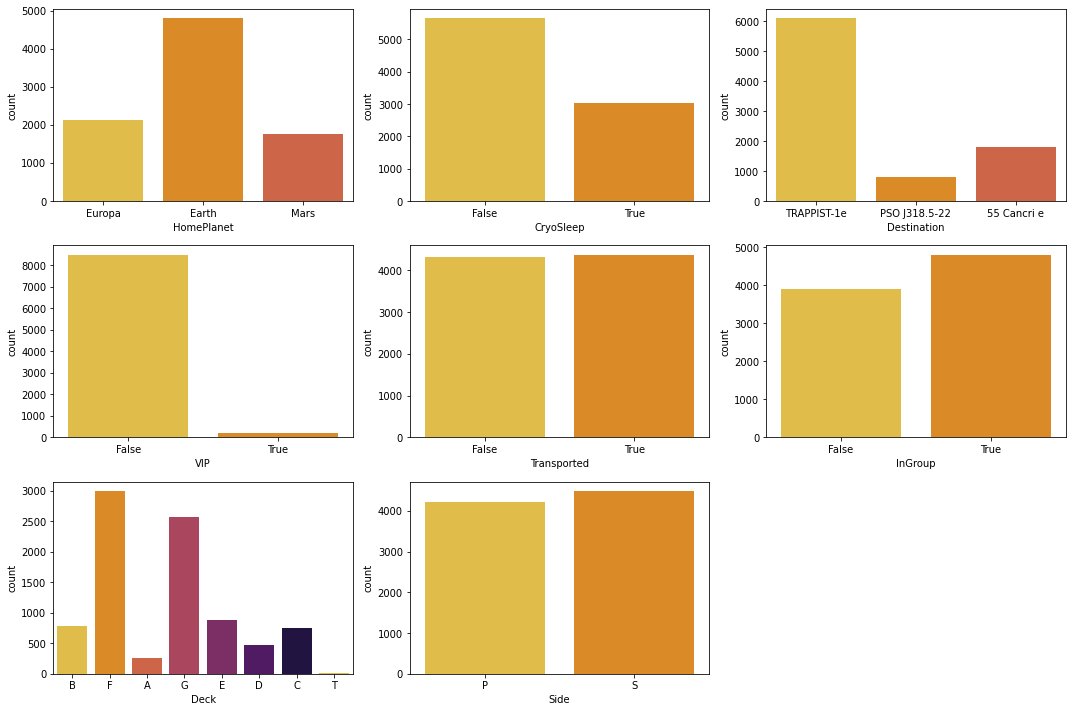

In [39]:
#Plot distribution of categorical columns
colors =sns.color_palette("inferno_r", 7)

fig = plt.figure(figsize= (15,10))
for i, col in enumerate(categ_feats):
    ax=fig.add_subplot(3, 3, i+1)
    sns.countplot(x=train_data[col],palette=colors, ax=ax)

fig.tight_layout()  
plt.show()

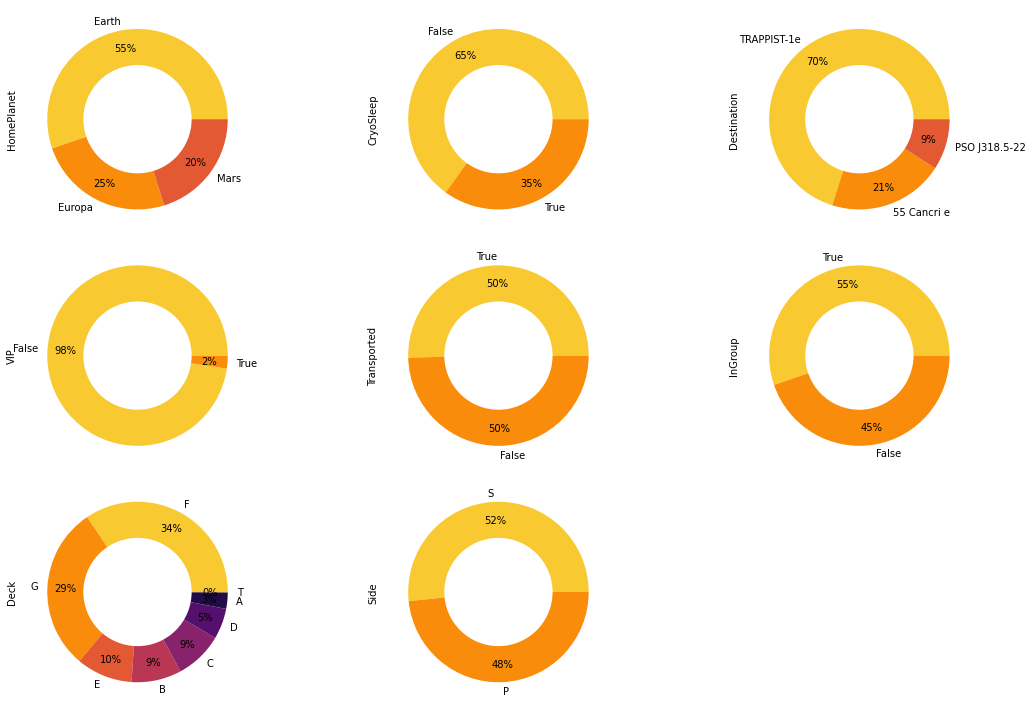

In [40]:
#Plot donut chart for each categorical column
fig = plt.figure(figsize= (16,10))
for i, col in enumerate(categ_feats):
    
    ax=fig.add_subplot( 3, 3, i+1)
    
    train_data[col].value_counts().plot.pie(autopct='%.0f%%', pctdistance=0.80, colors=sns.color_palette("inferno_r", 7))
    # draw circle
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    fig1 = plt.gcf()
    # Adding Circle in Pie chart
    fig1.gca().add_artist(centre_circle)
fig.tight_layout()  
plt.show()

# BIVARIATE ANALYSIS

**NUMERICAL - NUMERICAL analysis**

In [41]:
print("Number of numerical features:",len(num_feats))
num_feats

Number of numerical features: 7


['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Num']

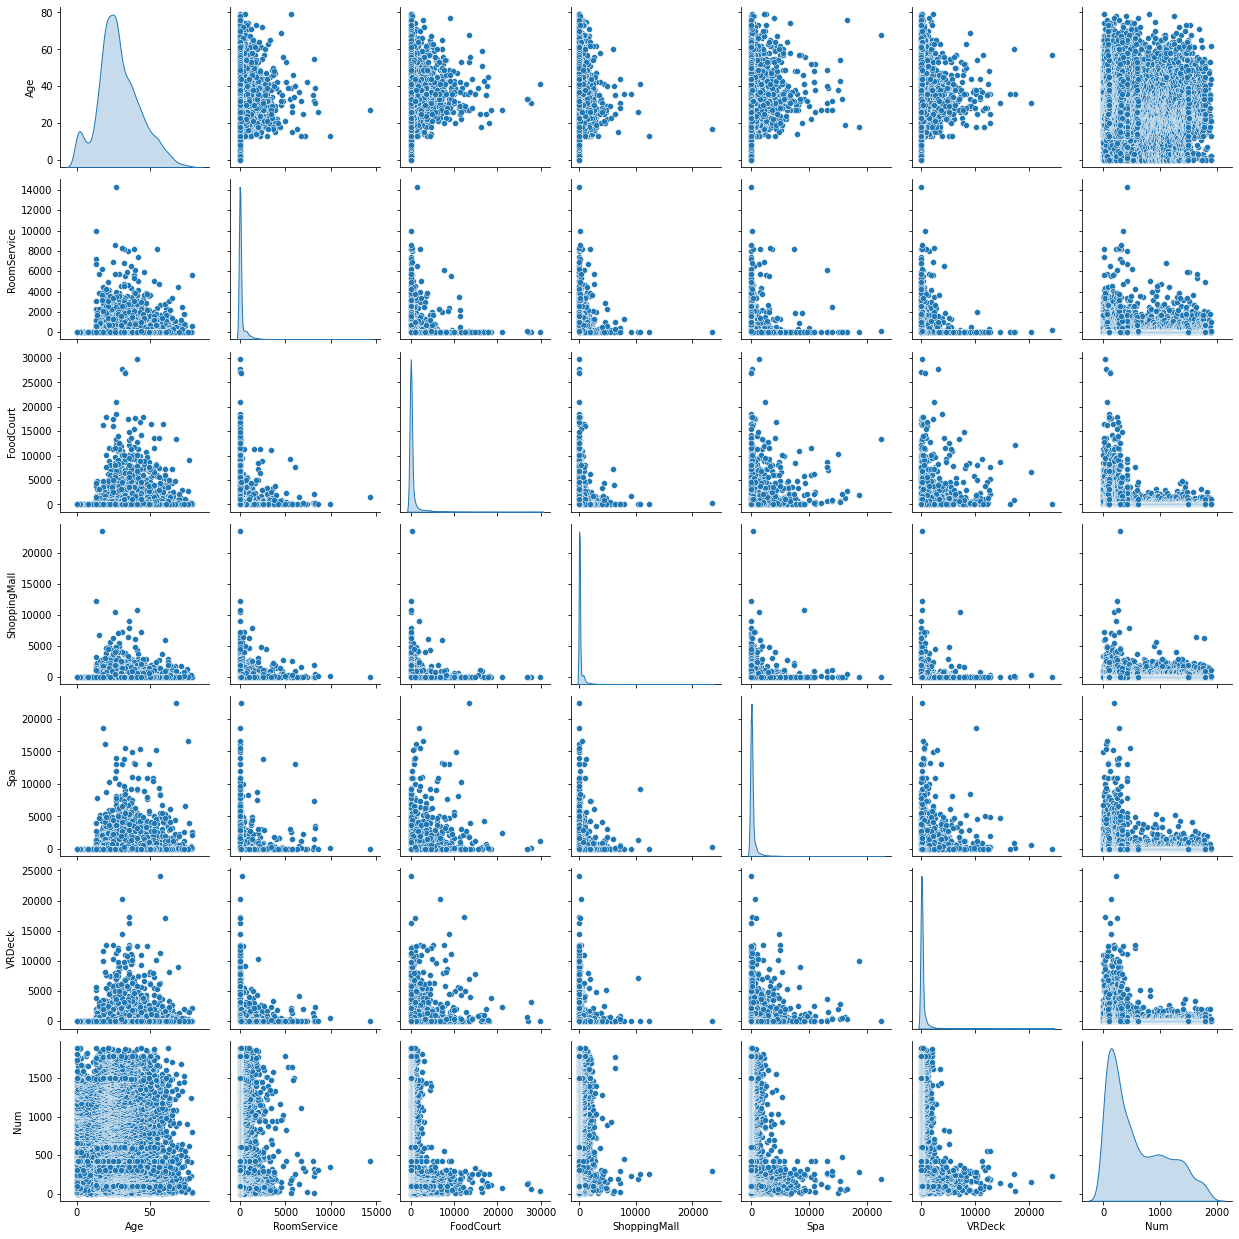

In [42]:
#plot the pair plot of numerical features
sns.pairplot(data = train_data, vars=num_feats, diag_kind="kde")

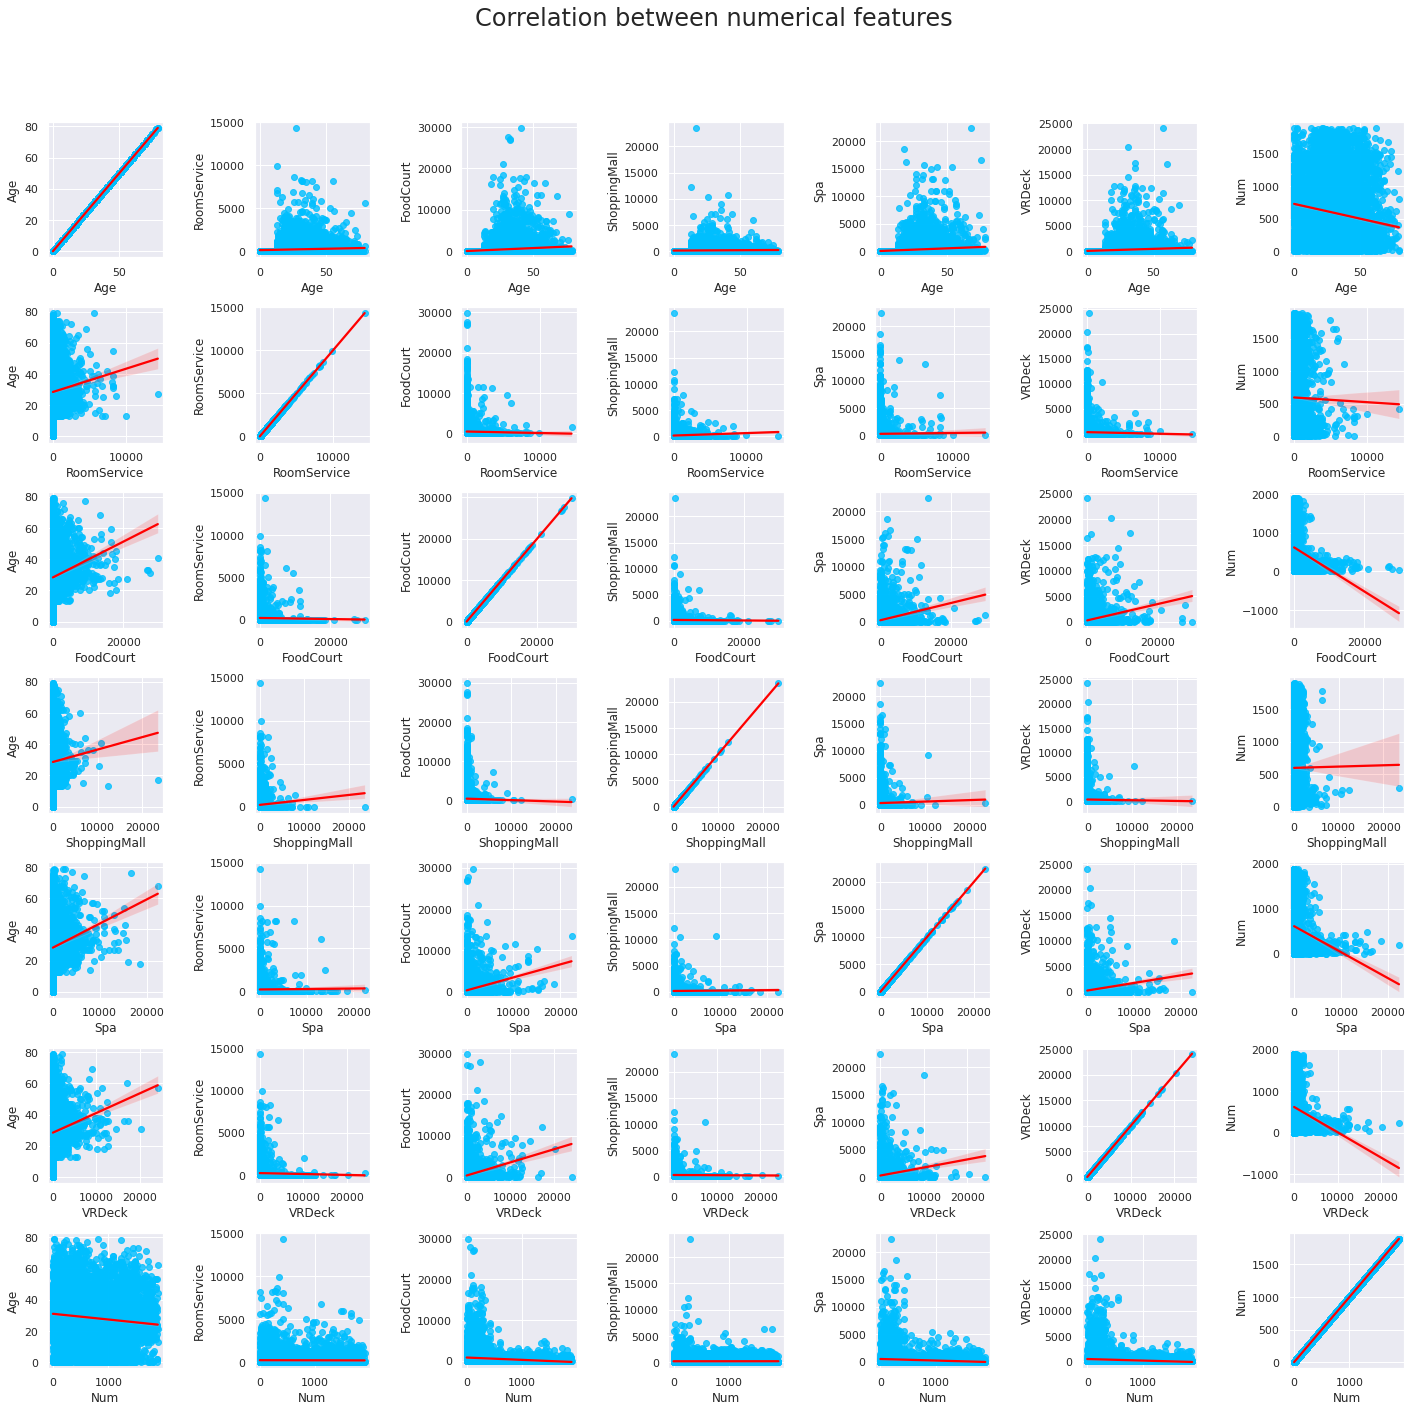

In [43]:
sns.set()
fig, axes = plt.subplots(len(num_feats), len(num_feats),figsize=(20, 20))
fig.suptitle('Correlation between numerical features', fontsize=24)
for i,col1 in enumerate(num_feats):
    for j,col2 in enumerate(num_feats):
        sns.regplot(x=col1,y=col2,data=train_data,color='blue', scatter_kws={
                    "color": "deepskyblue"}, line_kws={"color": "red"}, ax=axes[i,j])
fig.tight_layout()
plt.subplots_adjust(top=0.90)

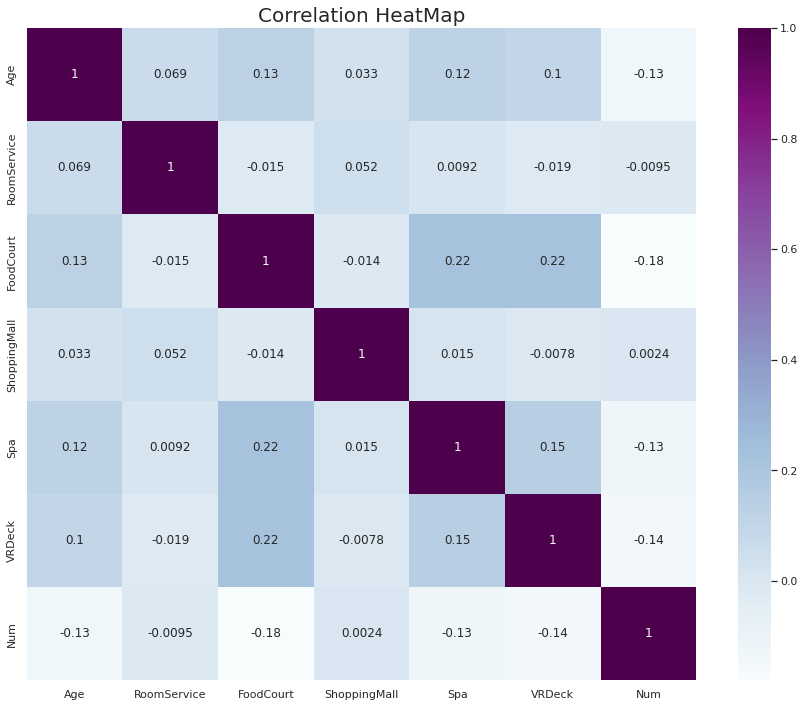

In [44]:
plt.figure(figsize=(15,12))
sns.heatmap(train_data[num_feats].corr(),cmap='BuPu',annot=True)
plt.title ('Correlation HeatMap', fontsize=20)
plt.show()

It seems that numerical features are not strongly correlated

**NUMERICAL - CATEGORICAL analysis**

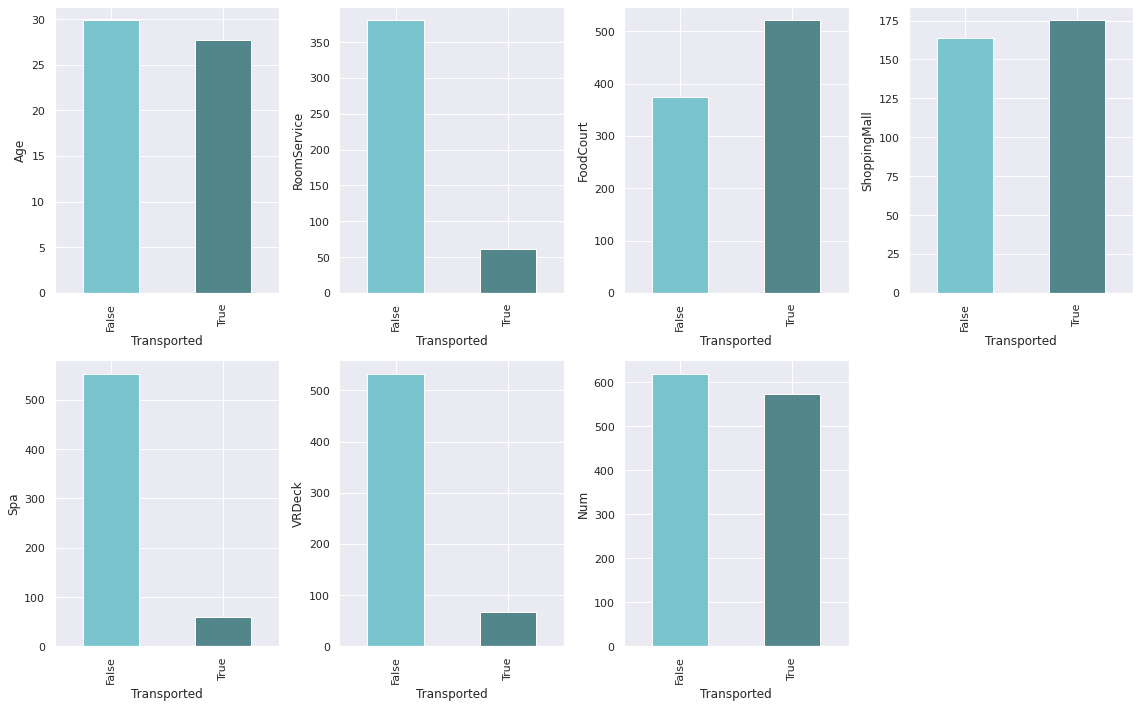

In [45]:
fig = plt.figure(figsize= (16,10))
for i, col in enumerate(num_feats):
    
    ax=fig.add_subplot( 2, 4, i+1)

    train_data.groupby(['Transported'])[col].mean().plot(kind='bar',color=["#7AC5CD","#53868B"])
    ax.set_ylabel(col)
fig.tight_layout()  
plt.show()

We can see that:
* the significant majority of the passengers who spent more on RoomService, Spa and VRDeck were not transported
* among the passengers who have spent a lot in FoodCourt, there is a slight majority were transported

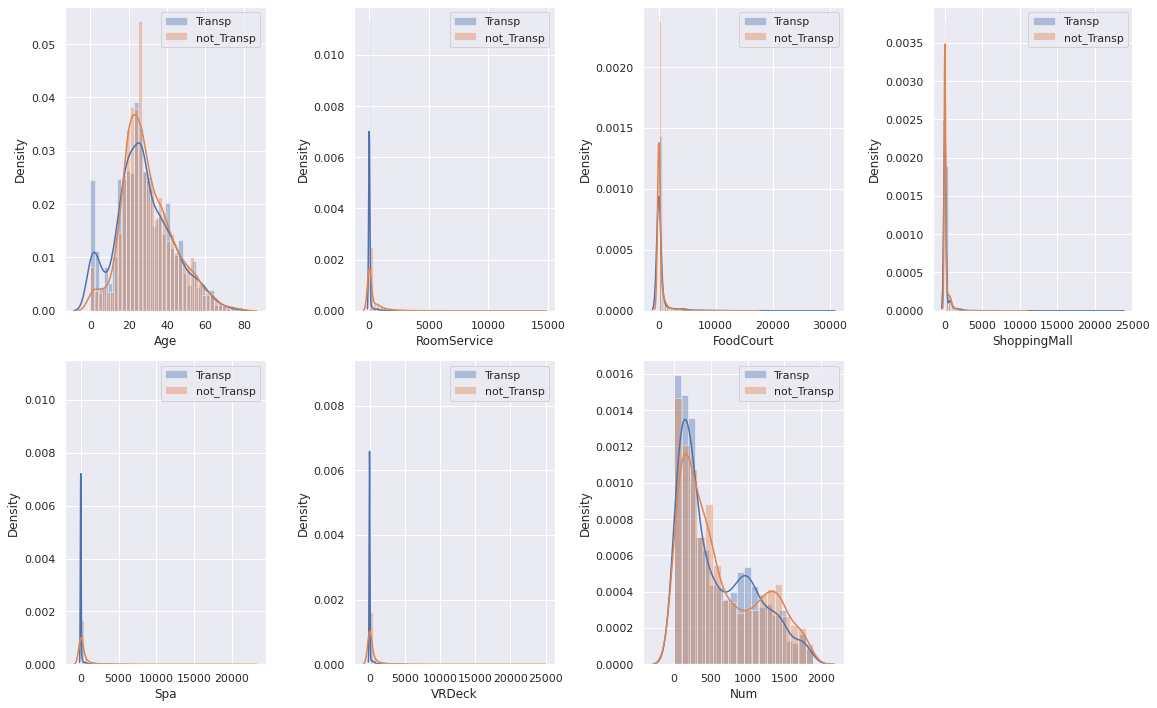

In [46]:
Transported_df=train_data[train_data['Transported']==True]
NotTransported_df=train_data[train_data['Transported']==False]
fig = plt.figure(figsize= (16,10))
for i, col in enumerate(num_feats):
    
    ax=fig.add_subplot( 2, 4, i+1)
    
    sns.distplot(Transported_df[col],label='Transp')
    sns.distplot(NotTransported_df[col],label='not_Transp')
    plt.legend()
    
fig.tight_layout()  
plt.show()

The distribution of each numerical feature for Transported and NoTransported passengers seems different. Therefore, these variables affect chances of being transported.

**CATEGORICAL - CATEGORICAL analysis**

<AxesSubplot:xlabel='Deck', ylabel='count'>

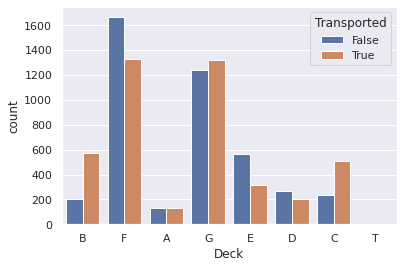

In [47]:
sns.countplot(x="Deck",data=train_data,hue="Transported")

<AxesSubplot:xlabel='Side', ylabel='count'>

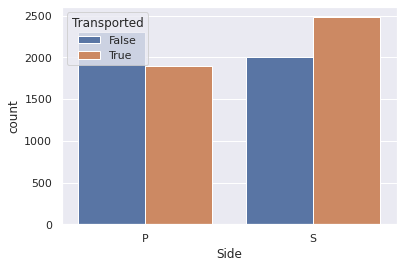

In [48]:
sns.countplot(x="Side",data=train_data,hue="Transported")

<div id = 3 style="color:white;    
           display:fill;
           border-radius:5px;
           background-color:#b0c4de;
           font-size:100%;
           font-family:Verdana;
           letter-spacing:0.5px;
           display:flex;
            justify-content:center;">

<h2 style="padding: 2rem;
              color:white;
          text-align:center;
          margin:0 auto;
          ">
    DATA PREPROCESSING
</h2>
</div>

In [49]:
train_data.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'InGroup',
       'Deck', 'Num', 'Side'],
      dtype='object')

In [50]:
train_data.dtypes

HomePlanet       object
CryoSleep          bool
Destination      object
Age             float64
VIP                bool
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported        bool
InGroup            bool
Deck             object
Num             float64
Side             object
dtype: object

In [51]:
train_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,InGroup,Deck,Num,Side
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,True,B,0.0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,True,F,0.0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,False,A,0.0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,False,A,0.0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,True,F,1.0,S


In [52]:
test_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,InGroup,Deck,Num,Side
0,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,True,G,3.0,S
1,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,True,F,4.0,S
2,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,True,C,0.0,S
3,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,True,C,1.0,S
4,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,True,F,5.0,S


In [53]:
LABELS = test_data.columns
encoder = LabelEncoder()
for col in LABELS:
    # Check if object
    if train_data[col].dtype == 'O':
        train_data[col] = encoder.fit_transform(train_data[col])
        test_data[col] = encoder.transform(test_data[col])
        
    elif train_data[col].dtype == 'bool':
        train_data[col] = train_data[col].astype('int')
        test_data[col] = test_data[col].astype('int')

train_data['Transported'] = train_data['Transported'].astype('int')
LABELS_MM = ['Age']
LABELS_SS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
mm_scaler = MinMaxScaler()
ss_scaler = StandardScaler()
# Apply Min-Max Scaling
train_data[LABELS_MM] = mm_scaler.fit_transform(train_data[LABELS_MM])
test_data[LABELS_MM] = mm_scaler.transform(test_data[LABELS_MM])
# Apply Standard Scaling
train_data[LABELS_SS] = ss_scaler.fit_transform(train_data[LABELS_SS])
test_data[LABELS_SS] = ss_scaler.transform(test_data[LABELS_SS])

In [54]:
train_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,InGroup,Deck,Num,Side
0,1,0,2,0.493671,0,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,0,1,1,0.0,0
1,0,0,2,0.303797,0,-0.168073,-0.275387,-0.241771,0.217158,-0.224205,1,1,5,0.0,1
2,1,0,2,0.734177,1,-0.268001,1.959998,-0.283579,5.695623,-0.219796,0,0,0,0.0,1
3,1,0,2,0.417722,0,-0.333105,0.523010,0.336851,2.687176,-0.092818,0,0,0,0.0,1
4,0,0,2,0.202532,0,0.125652,-0.237159,-0.031059,0.231374,-0.261240,1,1,5,1.0,1


In [55]:
test_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,InGroup,Deck,Num,Side
0,0,1,2,0.341772,0,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,1,6,3.0,1
1,0,0,2,0.240506,0,-0.333105,-0.275387,-0.283579,2.237598,-0.263003,1,5,4.0,1
2,1,1,0,0.392405,0,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,1,2,0.0,1
3,1,0,2,0.481013,0,-0.333105,3.887680,-0.283579,-0.109808,0.252842,1,2,1.0,1
4,0,0,2,0.253165,0,-0.317964,-0.281027,0.778343,-0.270626,-0.263003,1,5,5.0,1


In [56]:
x=train_data[['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'InGroup',
       'Deck', 'Num', 'Side']]
y=train_data['Transported']

In [57]:
x.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,InGroup,Deck,Num,Side
0,1,0,2,0.493671,0,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,1,1,0.0,0
1,0,0,2,0.303797,0,-0.168073,-0.275387,-0.241771,0.217158,-0.224205,1,5,0.0,1
2,1,0,2,0.734177,1,-0.268001,1.959998,-0.283579,5.695623,-0.219796,0,0,0.0,1
3,1,0,2,0.417722,0,-0.333105,0.523010,0.336851,2.687176,-0.092818,0,0,0.0,1
4,0,0,2,0.202532,0,0.125652,-0.237159,-0.031059,0.231374,-0.261240,1,5,1.0,1


<AxesSubplot:>

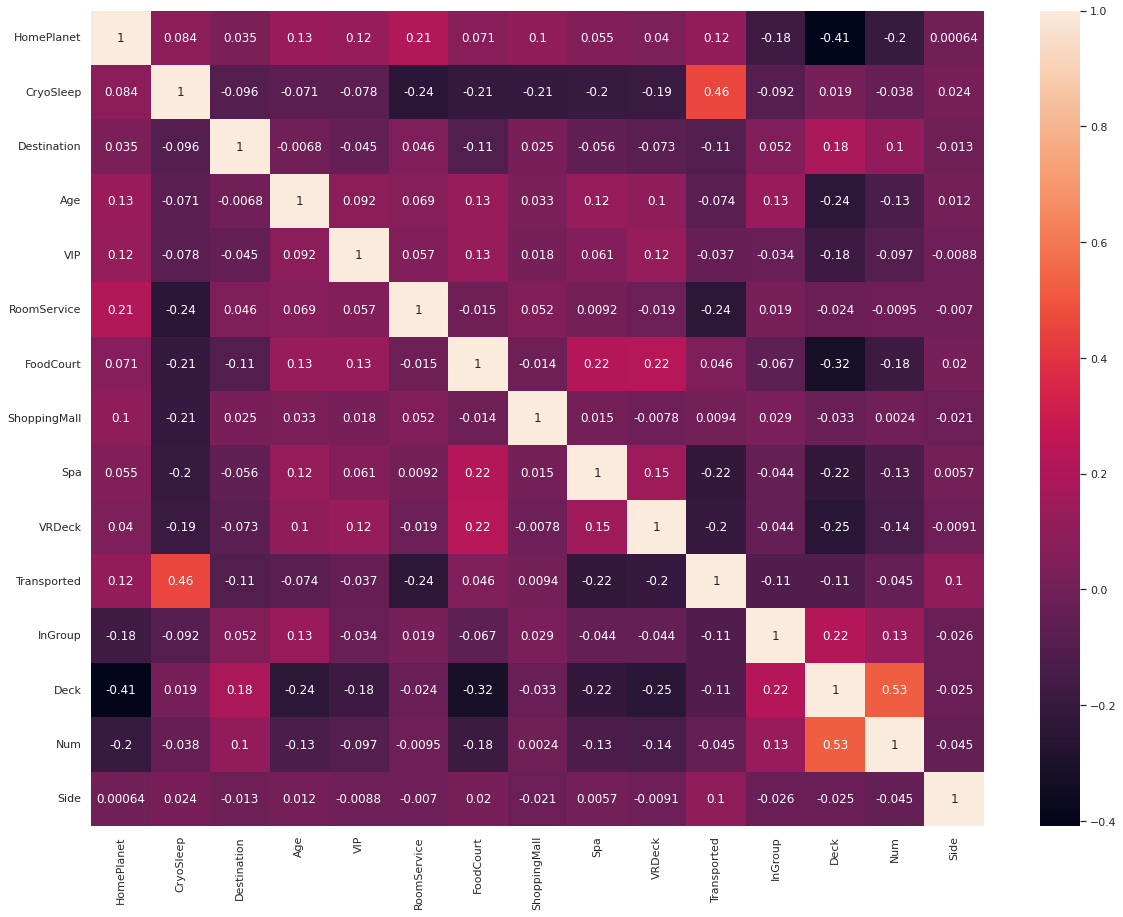

In [58]:
plt.figure(figsize=(20, 15))
sns.heatmap(train_data.corr(), annot=True)

<AxesSubplot:xlabel='CryoSleep', ylabel='Transported'>

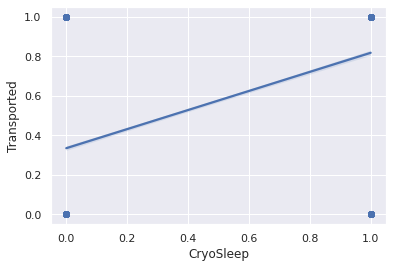

In [59]:
sns.regplot(train_data['CryoSleep'], train_data['Transported'], data=train_data)

There is a strong correlation between CryoSleep and Transported

<div id = 3 style="color:white;    
           display:fill;
           border-radius:5px;
           background-color:#b0c4de;
           font-size:100%;
           font-family:Verdana;
           letter-spacing:0.5px;
           display:flex;
            justify-content:center;">

<h2 style="padding: 2rem;
              color:white;
          text-align:center;
          margin:0 auto;
          ">
    MODEL SELECTION AND ML
</h2>
</div>

In [60]:
Xtr,Xte,ytr,yte = train_test_split(x,y,test_size=0.3,random_state=1)
Xtr.dtypes

HomePlanet        int64
CryoSleep         int64
Destination       int64
Age             float64
VIP               int64
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
InGroup           int64
Deck              int64
Num             float64
Side              int64
dtype: object

In [61]:
models = {} #dictionary containing all the models accuracies 

# VOTING CLASSIFIER

In [62]:
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC(probability=True)
cat_clf = CatBoostClassifier(verbose = 0)
grad_clf = GradientBoostingClassifier()
gaus_clf = GaussianNB()

In [63]:
voting_clf1 = VotingClassifier(
    estimators=[('lr',log_clf),('rf',rnd_clf),('svc',svm_clf),('cat',cat_clf),('grad',grad_clf)],
    voting='soft')
voting_clf1.fit(Xtr,ytr)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()),
                             ('svc', SVC(probability=True)),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x7f332f0c49d0>),
                             ('grad', GradientBoostingClassifier())],
                 voting='soft')

In [64]:
acc = accuracy_score(voting_clf1.predict(Xte),yte)
models[voting_clf1] = acc
print(acc)

0.8151840490797546


In [65]:
voting_clf2 = VotingClassifier(
    estimators=[('lr',log_clf),('rf',rnd_clf),('svc',svm_clf)], #,('cat',cat_clf),('xgb',xgb_clf)],
    voting='soft')

params = {'lr__C': [10, 1.0, 0.1],
        'rf__max_depth': [10, 50, 100, None],
        'svc__C': [10, 1.0, 0.1]}

grid = GridSearchCV(estimator=voting_clf2, param_grid=params, cv=2)

grid.fit(Xtr,ytr)


GridSearchCV(cv=2,
             estimator=VotingClassifier(estimators=[('lr',
                                                     LogisticRegression()),
                                                    ('rf',
                                                     RandomForestClassifier()),
                                                    ('svc',
                                                     SVC(probability=True))],
                                        voting='soft'),
             param_grid={'lr__C': [10, 1.0, 0.1],
                         'rf__max_depth': [10, 50, 100, None],
                         'svc__C': [10, 1.0, 0.1]})

In [66]:
print (grid.best_params_)
acc = accuracy_score(grid.predict(Xte),yte)
models[grid] = acc
print(acc)

{'lr__C': 10, 'rf__max_depth': 10, 'svc__C': 10}
0.8109662576687117


# BAGGING CLASSIFIER

In [67]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators = 500,
    max_samples=1000, bootstrap=True, n_jobs=-1)
bag_clf.fit(Xtr,ytr)


BaggingClassifier(base_estimator=DecisionTreeClassifier(), max_samples=1000,
                  n_estimators=500, n_jobs=-1)

In [68]:
acc = accuracy_score(bag_clf.predict(Xte),yte)
models[bag_clf] = acc
print(acc)

0.8040644171779141


# BOOSTING

In [69]:
params = { 'max_depth': [3,6,10],
           'learning_rate': [0.01, 0.05, 0.1],
           'n_estimators': [100, 500, 1000],
           'colsample_bytree': [0.3, 0.7]}

xgb_clf = XGBClassifier(seed = 20)

xgb_grid = GridSearchCV(estimator=xgb_clf, param_grid=params, cv=2)

xgb_grid.fit(Xtr,ytr)

GridSearchCV(cv=2,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_ca...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                  

In [70]:
acc = accuracy_score(xgb_grid.predict(Xte),yte)
models[xgb_grid] = acc
print(acc)

0.8121165644171779


# STACKING

In [71]:
estimators = [('rf',rnd_clf),('svc',svm_clf),('cat',cat_clf),('grad',grad_clf)]

st_clf = StackingClassifier(
     estimators=estimators, final_estimator=LogisticRegression()
)

st_clf.fit(Xtr,ytr)

StackingClassifier(estimators=[('rf', RandomForestClassifier()),
                               ('svc', SVC(probability=True)),
                               ('cat',
                                <catboost.core.CatBoostClassifier object at 0x7f332f0c49d0>),
                               ('grad', GradientBoostingClassifier())],
                   final_estimator=LogisticRegression())

In [72]:
acc = accuracy_score(st_clf.predict(Xte),yte)
models[st_clf] = acc
print(acc)

0.8155674846625767


In [73]:
models

{VotingClassifier(estimators=[('lr', LogisticRegression()),
                              ('rf', RandomForestClassifier()),
                              ('svc', SVC(probability=True)),
                              ('cat',
                               <catboost.core.CatBoostClassifier object at 0x7f332f0c49d0>),
                              ('grad', GradientBoostingClassifier())],
                  voting='soft'): 0.8151840490797546,
 GridSearchCV(cv=2,
              estimator=VotingClassifier(estimators=[('lr',
                                                      LogisticRegression()),
                                                     ('rf',
                                                      RandomForestClassifier()),
                                                     ('svc',
                                                      SVC(probability=True))],
                                         voting='soft'),
              param_grid={'lr__C': [10, 1.0, 0.1],
            

In [74]:
best_model = max(models, key=models.get)
best_model

StackingClassifier(estimators=[('rf', RandomForestClassifier()),
                               ('svc', SVC(probability=True)),
                               ('cat',
                                <catboost.core.CatBoostClassifier object at 0x7f332f0c49d0>),
                               ('grad', GradientBoostingClassifier())],
                   final_estimator=LogisticRegression())

The most trivial solution may be to take the model that showed the highest accuracy. However, the generalization capacity of a model must also be taken into account. XGBoost, despite having obtained a slightly lower accuracy than the others, is the most generalizable model.

**PREDICTION**

In [75]:
pred=pd.Series(xgb_grid.predict(test_data)).map({0:False, 1:True})
len(pred)

4277

In [76]:
submission = pd.DataFrame({'PassengerId': Id_test_list,
                       'Transported': pred})
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [77]:
submission

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


In [78]:
submission.to_csv("submission.csv", index=False)

<div id = 3 style="color:white;    
           display:fill;
           border-radius:5px;
           background-color:#b0c4de;
           font-size:100%;
           font-family:Verdana;
           letter-spacing:0.5px;
           display:flex;
            justify-content:center;">

<h2 style="padding: 2rem;
              color:white;
          text-align:center;
          margin:0 auto;
          ">
    END
</h2>
</div>

# Thank you for your attention and please let me know what you think. Any doubts or suggestions are welcome! 🙂